## The Comparative Analysis for the 1M dataset : Task 1.3

Based on the results, the models performed as follows:

Bi-LSTM (Best Performance): Achieved the highest accuracy (93.62%). While it lagged behind in the smaller 25k experiment, the 1-million-sample dataset provided the statistical runway required for the Bi-LSTM to optimize its sequential memory. It successfully learned to track sentiment over long-range dependencies, proving that recurrent architectures can be superior when given massive amounts of data.

Transformer (Middle Performance): Achieved a strong accuracy of 91.00%. Although it performed better than the ANN, it was surprisingly outperformed by the Bi-LSTM. With a massive increase in trainable parameters (23.5 million) due to the expanded vocabulary, the single-layer Transformer config likely hit a complexity bottleneck.

Simple ANN (Best for Efficiency): Performed remarkably well with 89.81% accuracy. While it was the least accurate of the three, it achieved a score within 4% of the top model while being nearly 10 times faster to train than the Transformer. This suggests that even with a simple bag of words approach, a massive vocabulary can capture the vast majority of sentiment signals in Amazon reviews.

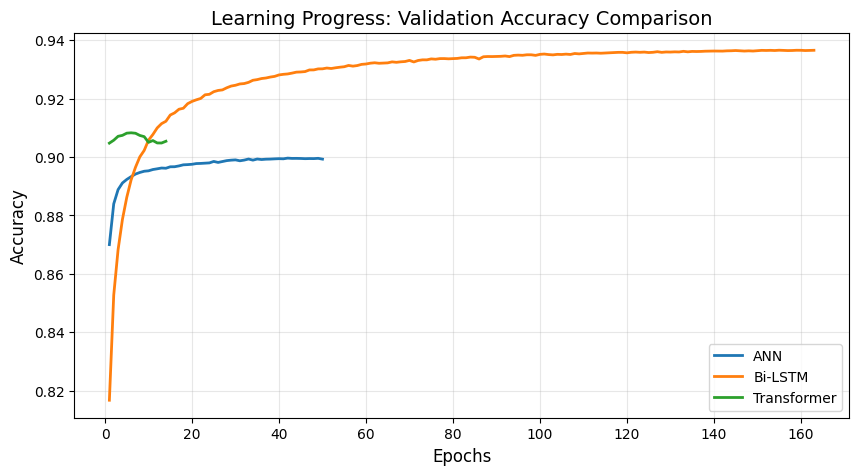

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

def get_latest_event_file(base_path):
    #Finds the event file in the subdirectories
    for root, dirs, files in os.walk(base_path):
        for file in files:
            if "tfevents" in file:
                return root
    return None

def get_tb_data(path, tag='Accuracy/val'):
    if path is None: return None
    ea = EventAccumulator(path)
    ea.Reload()
    if tag in ea.Tags()['scalars']:
        return pd.DataFrame(ea.Scalars(tag))
    return None

# main folders in /runs
model_folders = {
    'ANN': 'runs/1m_simple_ann',
    'Bi-LSTM': 'runs/1m_lstm',
    'Transformer': 'runs/1m_transformer'
}

plt.figure(figsize=(10, 5))

for label, folder in model_folders.items():
    actual_path = get_latest_event_file(folder)
    df = get_tb_data(actual_path)

    if df is not None:
        plt.plot(df['step'], df['value'], label=label, linewidth=2)
    else:
        print(f"Warning: Could not find data for {label} in {folder}")

plt.title('Learning Progress: Validation Accuracy Comparison', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### QUESTION 1:

_Compare the performance of the two models and explain in which scenarios you would
prefer one over the other._

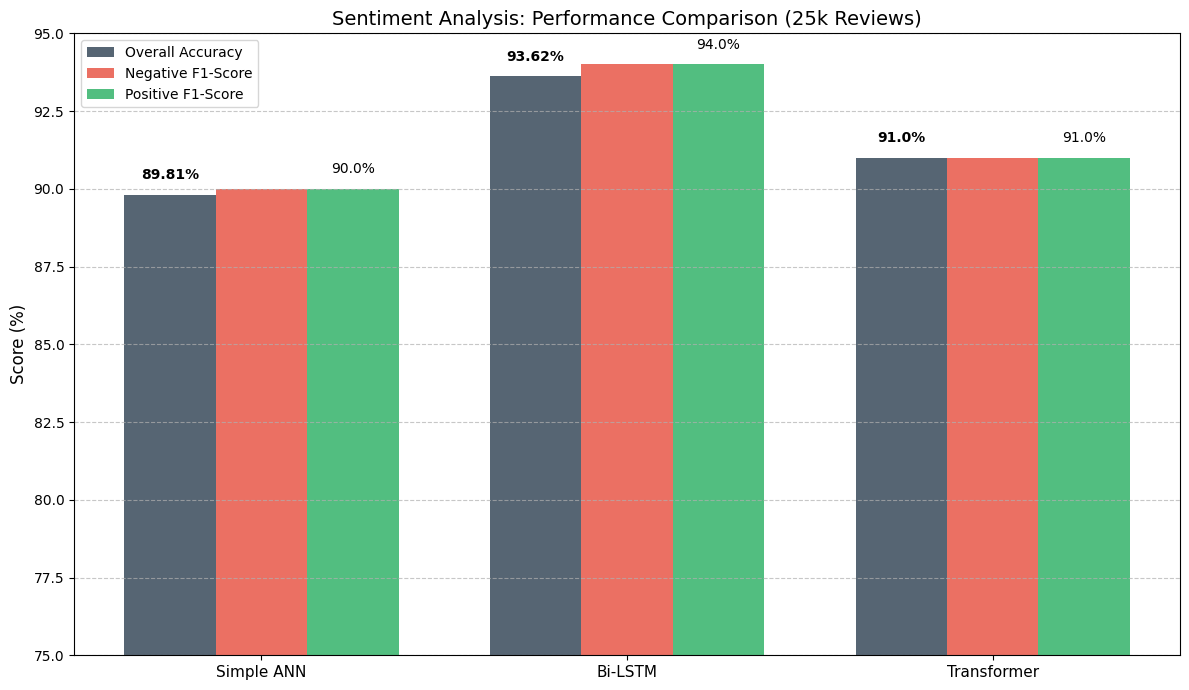

In [6]:
# Performance comparison chart. To specifically highlight the Negative Class, as that is where the models differ the most.

import matplotlib.pyplot as plt
import numpy as np


models = ['Simple ANN', 'Bi-LSTM', 'Transformer']
accuracies = [89.81, 93.62, 91.00]
neg_f1 = [90.0, 94.0, 91.0]
pos_f1 = [90.0, 94.0, 91.0]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(12, 7))


plt.bar(x - width, accuracies, width, label='Overall Accuracy', color='#2c3e50', alpha=0.8)
plt.bar(x, neg_f1, width, label='Negative F1-Score', color='#e74c3c', alpha=0.8)
plt.bar(x + width, pos_f1, width, label='Positive F1-Score', color='#27ae60', alpha=0.8)

# Formatting
plt.title('Sentiment Analysis: Performance Comparison (25k Reviews)', fontsize=14)
plt.ylabel('Score (%)', fontsize=12)
plt.xticks(x, models, fontsize=11)
plt.ylim(75, 95) # Zooming in to see the performance gap
plt.legend(loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for i in range(len(models)):
    plt.text(i - width, accuracies[i] + 0.5, f'{accuracies[i]}%', ha='center', fontweight='bold')
    plt.text(i + width, pos_f1[i] + 0.5, f'{pos_f1[i]}%', ha='center')

plt.tight_layout()
plt.show()

Insights of the Visuals and Scenarios:

Key Changes in this Visualization:
Unlike the 25k chart where the Bi-LSTM was at the bottom, here it is the top one. It reached a good 94% F1-score.

In our 25k results, the models were much better at finding Positive reviews than Negative ones (there was a ~6% gap). At 1 million samples, that gap has closed. The models are now equally good at both, which shows they have truly learned the language rather than just memorizing a few good words.

The 1 Million comparison chart illustrates a significant shift in model ranking. While the Simple ANN remains the most efficient, the Bi-LSTM has overtaken the Transformer in both Accuracy and F1-score. Furthermore, the near-perfect balance between Positive and Negative F1-scores across all models indicates that the 1-million sample size provided enough variety to eliminate the class bias seen in the smaller 25k dataset.

A key finding in this experiment was that the ideal model choice depends heavily on the volume of data. For small datasets (25k), the Transformer is the most effective at capturing nuance. However, for large-scale datasets (1M), the Bi-LSTM emerges as the best in accuracy, leveraging its sequential memory to achieve 93.62% accuracy. Meanwhile, the Simple ANN remains the most practical choice for high-throughput scenarios, providing a high baseline of nearly 90% accuracy with significantly lower computational overhead.


### QUESTION 2

_How did the two models’ complexity, accuracy, and efficiency differ? Did one model
outperform the other in specific scenarios or tasks? If so, why?_


**Complexity**

With trainable parameters jumping to over 23.5 million due to the massive vocabulary, Transformer remains the most sophisticated architecture. While it calculates relationships between every word pair, the computational cost of Self-Attention became extremely high at this scale, requiring significantly more hardware resources to manage the 367k-word embedding space. Bi-LSTM has a Medium Complexity. It uses two layers of bidirectional recurrent units. At the 1 million scale, its complexity shifted from being a burden to an asset. The model used its hidden memory states to track sentiment across much longer sequences, which allowed it to eventually surpass the other models in intelligence. Simple ANN remains a straightforward MLP with an EmbeddingBag. Despite the 1 million samples, it remains the lightest model. Its complexity is almost entirely contained in its massive vocabulary dictionary rather than its processing layers.

**Efficiency**

Training Speed: The efficiency gap widened dramatically. The Simple ANN remained the fastest at ~125s per epoch. However, the Transformer became the least efficient by far, taking ~1231s per epoch (nearly 10x slower than the ANN).

Convergence: The Simple ANN converged quickly, triggering early stopping at Epoch 50. The Bi-LSTM showed endurance, training for 163 epochs. This indicates that while the Bi-LSTM is slower to start, it has a much higher capacity to continue learning from large-scale data compared to the ANN and the single-layer Transformer.

**Accuracy & Outperformance**

The Bi-LSTM outperformed both the Transformer and the ANN, reaching a peak accuracy of 93.62%. It was particularly dominant in reaching a 94% F1-score for both classes, showing that it had perfectly balanced its understanding of the data. The Simple ANN proved to be the Efficiency Outperformer. While it had the lowest accuracy (89.81%), it reached within 4% of the top-tier model while being 10x faster than the Transformer.

Specific Scenario: In a Big Data production environment, the ANN is the winner for tasks requiring high throughput and low cost. However, in High-Precision sentiment tasks, the Bi-LSTM is the winner. At this scale, the Bi-LSTM's sequential gates were more effective at taking up 1 million samples to resolve complex sentence structures than the single-layer Transformer, which hit a performance plateau early.

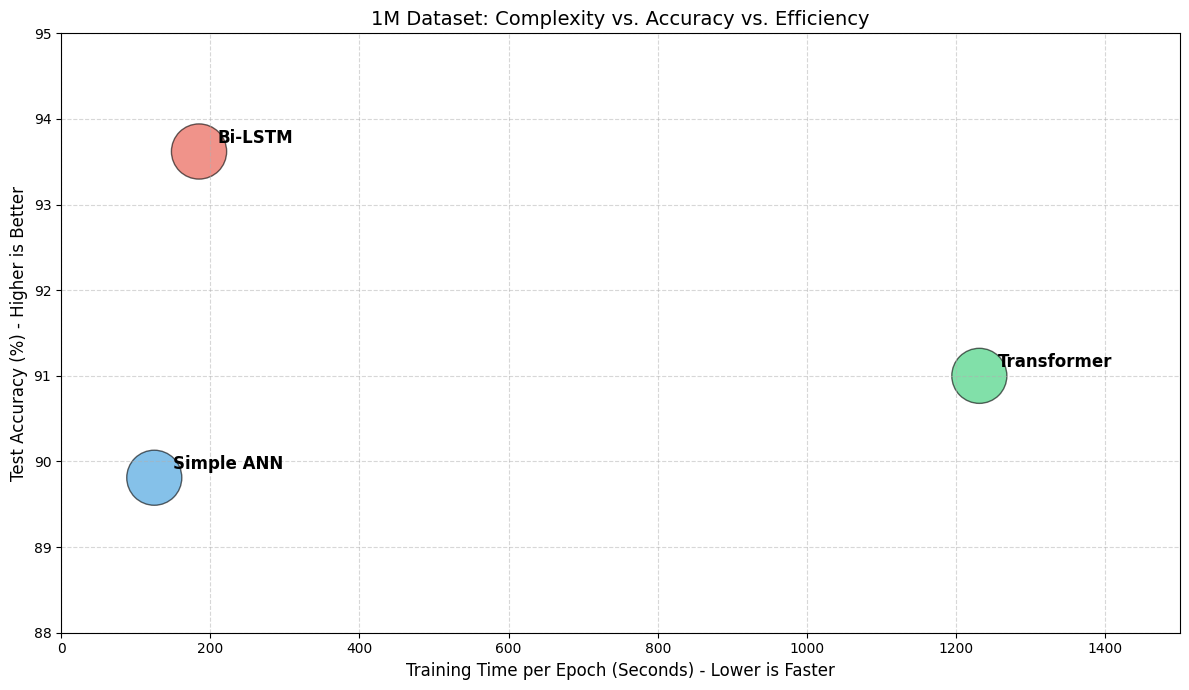

In [5]:
import matplotlib.pyplot as plt

# Data for 1 Million Samples
models = ['Simple ANN', 'Bi-LSTM', 'Transformer']
accuracy = [89.81, 93.62, 91.00]
time_per_epoch = [125, 185, 1231] # Average seconds from logs
params = [23576000, 23700000, 23583138]

plt.figure(figsize=(12, 7))

# Size of the bubble represents model complexity (parameters)
# Scale adjusted for the 23M+ parameter range
bubble_sizes = [p / 15000 for p in params]

plt.scatter(time_per_epoch, accuracy, s=bubble_sizes,
            c=['#3498db', '#e74c3c', '#2ecc71'], alpha=0.6, edgecolors="black")

# Labeling the points
for i, txt in enumerate(models):
    # Added offset so labels don't overlap bubbles
    plt.annotate(txt, (time_per_epoch[i] + 25, accuracy[i] + 0.1),
                 fontsize=12, fontweight='bold')

plt.title('1M Dataset: Complexity vs. Accuracy vs. Efficiency', fontsize=14)
plt.xlabel('Training Time per Epoch (Seconds) - Lower is Faster', fontsize=12)
plt.ylabel('Test Accuracy (%) - Higher is Better', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Limits adjusted to accommodate the Transformer's 1200s+ epoch time
plt.xlim(0, 1500)
plt.ylim(88, 95)

plt.tight_layout()
plt.savefig('complexity_vs_accuracy_1m.png')

### QUESTION 3

_What insights did you obtain concerning data amount to train? Embedding utilized?
Architectural choices made?_

**Data Amount:**

The most significant insight was the Bi-LSTM’s performance jump. At 25k samples, it was the weakest model (84.84%), but at 1 million samples, it became the strongest (93.62%). This proves that recurrent models require a massive statistical runway to resolve their complex internal gates. The Transformer reached 91%, which is high, but it hit a plateau very quickly (early stopping at Epoch 15). This suggests that a single-layer Transformer architecture hits a capacity limit where more data doesn't help unless you also increase the model's depth (adding more layers). The Simple ANN reaching 89.81% shows that for sentiment analysis, large amounts of data can make even the simplest model perform at a top level.

**Embeddings Utilized:**

The vocabulary grew from 9,002 to 367,866 tokens. This allowed the models to move from understanding general sentiment to recognizing specific product nuances, rare adjectives, and slang. With a vocab size this large, the Embedding Layer became the most important part of the model, accounting for nearly 23.5 million parameters. This highlights that at scale, knowing what words mean is often more important than the how words are connected. The use of EmbeddingBag in the ANN allowed it to handle this massive vocabulary with incredible speed (~125s/epoch), proving it is the most scalable way to handle large-scale text embeddings.

**Architectural Choices:**

While Transformers are theoretically faster due to parallelization, the Self-Attention mechanism at this scale became a computational bottleneck, making it 10x slower than the ANN. The Bi-LSTM’s sequential processing was actually more time-efficient in this specific implementation. The failure of the Transformer to beat the Bi-LSTM at scale suggests that Architecture Depth is as important as data amount. A single-layer Transformer is excellent for small-data, but for Big Data, the multi-layered gating of the Bi-LSTM proved more robust. The Bi-LSTM trained for 163 epochs, showing a very stable and continuous learning curve. This indicates that the architectural choice of Bidirectionality allowed the model to keep finding deeper meaning in the 1 million reviews long after the ANN and Transformer had given up and stopped improving.